# 🇮🇳 India Unemployment Analysis using Python

## 📊 CodeAlpha Data Science Internship – Task 2

---

## 👨‍💻 Developed By

**Gaurav Eknath Kumbhar**

🎓 MCA Student | Aspiring Data Scientist

---

## 📖 Project Overview

This project analyzes unemployment trends across India using Python by performing data cleaning, exploratory data analysis (EDA), feature engineering, interactive visualizations, and COVID-19 impact analysis.

The notebook is designed to generate meaningful insights into employment patterns and labour participation while demonstrating professional data analysis techniques.

---

## 🎯 Project Objectives

- Clean and preprocess unemployment datasets
- Explore unemployment trends across India
- Analyze employment and labour participation
- Investigate the impact of COVID-19
- Identify seasonal and regional patterns
- Create interactive visualizations using Plotly
- Build a professional Streamlit dashboard
- Present insights to support economic and social policy decisions

---

## 🛠️ Technologies Used

- Python
- Pandas
- NumPy
- Plotly
- Matplotlib
- Seaborn
- Jupyter Notebook
- Streamlit

---

## 📂 Datasets Used

1. **Unemployment in India.csv**
2. **Unemployment_Rate_upto_11_2020.csv**

---

## 📈 Expected Deliverables

- ✔️ Professional Data Cleaning
- ✔️ Feature Engineering
- ✔️ 40+ Interactive Visualizations
- ✔️ Time Series Analysis
- ✔️ COVID-19 Impact Analysis
- ✔️ Executive Dashboard
- ✔️ Streamlit Web Application
- ✔️ GitHub Portfolio Project

---

> **Internship:** CodeAlpha – Data Science Internship

In [10]:
# ============================================================
# 📚 Import Required Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import os
from pathlib import Path

# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Interactive Visualization
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

# Display Tables
from IPython.display import display

# ============================================================
# Notebook Configuration
# ============================================================

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

# Plotly Theme
pio.templates.default = "plotly_dark"

# ============================================================
# Professional Color Palette
# ============================================================

COLORS = {
    "primary": "#2563EB",
    "secondary": "#14B8A6",
    "success": "#22C55E",
    "warning": "#F59E0B",
    "danger": "#EF4444",
    "purple": "#7C3AED",
    "pink": "#EC4899",
    "gray": "#6B7280"
}

# ============================================================
# Create Project Folders
# ============================================================

folders = [
    "Images",
    "Reports",
    "Exports"
]

for folder in folders:
    Path(folder).mkdir(exist_ok=True)

# ============================================================
# Helper Function
# ============================================================

def show_chart(fig, filename=None):
    """
    Display Plotly chart and optionally save it as HTML.
    """
    fig.show()

    if filename:
        fig.write_html(f"Images/{filename}.html")

print("=" * 60)
print("✅ All libraries loaded successfully.")
print("✅ Notebook environment configured.")
print("✅ Plotly theme set to 'plotly_dark'.")
print("✅ Project folders created.")
print("✅ Helper functions are ready.")
print("=" * 60)

✅ All libraries loaded successfully.
✅ Notebook environment configured.
✅ Plotly theme set to 'plotly_dark'.
✅ Project folders created.
✅ Helper functions are ready.


In [11]:
# ============================================================
# 📂 Load the Datasets
# ============================================================

try:
    # Dataset 1
    unemployment_df = pd.read_csv("Unemployment in India.csv")

    # Dataset 2
    covid_df = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

    print("✅ Both datasets loaded successfully!")

except FileNotFoundError:
    print("❌ CSV file not found.")
    print("➡️ Make sure both CSV files are in the same folder as this notebook.")

✅ Both datasets loaded successfully!


# 📊 Section 4 — Dataset Verification

## 🎯 Objective

After loading the datasets, it is important to verify that they have been imported correctly.

Dataset verification is one of the first steps in every Data Science project because it provides an overview of the data before preprocessing and analysis.

---

### In this section, we will:

- Check the number of rows and columns
- Display dataset dimensions
- View memory usage
- Compare both datasets
- Generate a quick dataset summary

---

### Why is this important?

Understanding the dataset's size and structure helps estimate the complexity of the analysis and identifies potential issues before moving on to data cleaning and exploratory analysis.

In [12]:
# ============================================================
# 📊 Dataset Verification
# ============================================================

print("=" * 70)
print("📂 DATASET 1 : Unemployment in India")
print("=" * 70)

print(f"Rows    : {unemployment_df.shape[0]:,}")
print(f"Columns : {unemployment_df.shape[1]}")

print("\n")

print("=" * 70)
print("📂 DATASET 2 : Unemployment Rate upto 11_2020")
print("=" * 70)

print(f"Rows    : {covid_df.shape[0]:,}")
print(f"Columns : {covid_df.shape[1]}")

print("\n")

summary = pd.DataFrame({
    "Dataset": [
        "Unemployment in India",
        "Unemployment Rate upto 11_2020"
    ],
    "Rows": [
        unemployment_df.shape[0],
        covid_df.shape[0]
    ],
    "Columns": [
        unemployment_df.shape[1],
        covid_df.shape[1]
    ],
    "Memory (KB)": [
        round(unemployment_df.memory_usage(deep=True).sum()/1024, 2),
        round(covid_df.memory_usage(deep=True).sum()/1024, 2)
    ]
})

display(
    summary.style
    .set_caption("📋 Dataset Summary")
    .background_gradient(cmap="Blues")
)

📂 DATASET 1 : Unemployment in India
Rows    : 768
Columns : 7


📂 DATASET 2 : Unemployment Rate upto 11_2020
Rows    : 267
Columns : 9




,Dataset,Rows,Columns,Memory (KB)
0,Unemployment in India,768,7,186.830000
1,Unemployment Rate upto 11_2020,267,9,68.780000


# 📖 Section 4 — Dataset Understanding

## 🎯 Objective

Before cleaning or analyzing the data, it is important to understand its structure and contents.

Dataset understanding helps identify:

- Number of features
- Column names
- Data types
- Sample records
- Missing values
- Data quality issues
- Overall dataset characteristics

---

## 📌 What We Will Explore

- Dataset Shape
- Column Names
- Data Types
- Sample Records
- Statistical Summary
- Missing Values
- Unique Values
- Duplicate Records

---

### 🎯 Expected Outcome

By the end of this section, we will have a clear understanding of both datasets and identify any issues that need to be addressed during data cleaning.

In [13]:
# ============================================================
# 📋 Display First Five Records
# ============================================================

print("=" * 70)
print("📂 Dataset 1 - First Five Records")
print("=" * 70)

display(unemployment_df.head())

print("\n")

print("=" * 70)
print("📂 Dataset 2 - First Five Records")
print("=" * 70)

display(covid_df.head())

📂 Dataset 1 - First Five Records


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.00,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.00,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.00,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.00,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.00,44.68,Rural




📂 Dataset 2 - First Five Records


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.91,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.91,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.91,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.91,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.91,79.74


In [14]:
# ============================================================
# 📋 Display Column Names
# ============================================================

print("=" * 70)
print("📂 Dataset 1 - Column Names")
print("=" * 70)

dataset1_columns = pd.DataFrame({
    "Column Number": range(1, len(unemployment_df.columns) + 1),
    "Column Name": unemployment_df.columns
})

display(
    dataset1_columns.style
    .set_caption("📋 Dataset 1 Features")
    .background_gradient(cmap="Blues")
)

print("\n")

print("=" * 70)
print("📂 Dataset 2 - Column Names")
print("=" * 70)

dataset2_columns = pd.DataFrame({
    "Column Number": range(1, len(covid_df.columns) + 1),
    "Column Name": covid_df.columns
})

display(
    dataset2_columns.style
    .set_caption("📋 Dataset 2 Features")
    .background_gradient(cmap="Greens")
)

📂 Dataset 1 - Column Names


,Column Number,Column Name
0,1,Region
1,2,Date
2,3,Frequency
3,4,Estimated Unemployment Rate (%)
4,5,Estimated Employed
5,6,Estimated Labour Participation Rate (%)
6,7,Area




📂 Dataset 2 - Column Names


,Column Number,Column Name
0,1,Region
1,2,Date
2,3,Frequency
3,4,Estimated Unemployment Rate (%)
4,5,Estimated Employed
5,6,Estimated Labour Participation Rate (%)
6,7,Region.1
7,8,longitude
8,9,latitude


In [15]:
# ============================================================
# 📊 Check Data Types and Memory Usage
# ============================================================

print("=" * 70)
print("📂 Dataset 1 - Data Types")
print("=" * 70)

dataset1_info = pd.DataFrame({
    "Column Name": unemployment_df.columns,
    "Data Type": unemployment_df.dtypes.astype(str),
    "Non-Null Count": unemployment_df.count().values,
    "Missing Values": unemployment_df.isnull().sum().values
})

display(
    dataset1_info.style
    .set_caption("📋 Dataset 1 - Column Information")
    .background_gradient(cmap="Blues")
)

print("\n")

print("=" * 70)
print("📂 Dataset 2 - Data Types")
print("=" * 70)

dataset2_info = pd.DataFrame({
    "Column Name": covid_df.columns,
    "Data Type": covid_df.dtypes.astype(str),
    "Non-Null Count": covid_df.count().values,
    "Missing Values": covid_df.isnull().sum().values
})

display(
    dataset2_info.style
    .set_caption("📋 Dataset 2 - Column Information")
    .background_gradient(cmap="Greens")
)

📂 Dataset 1 - Data Types


,Column Name,Data Type,Non-Null Count,Missing Values
Region,Region,object,740,28
Date,Date,object,740,28
Frequency,Frequency,object,740,28
Estimated Unemployment Rate (%),Estimated Unemployment Rate (%),float64,740,28
Estimated Employed,Estimated Employed,float64,740,28
Estimated Labour Participation Rate (%),Estimated Labour Participation Rate (%),float64,740,28
Area,Area,object,740,28




📂 Dataset 2 - Data Types


,Column Name,Data Type,Non-Null Count,Missing Values
Region,Region,object,267,0
Date,Date,object,267,0
Frequency,Frequency,object,267,0
Estimated Unemployment Rate (%),Estimated Unemployment Rate (%),float64,267,0
Estimated Employed,Estimated Employed,int64,267,0
Estimated Labour Participation Rate (%),Estimated Labour Participation Rate (%),float64,267,0
Region.1,Region.1,object,267,0
longitude,longitude,float64,267,0
latitude,latitude,float64,267,0


In [16]:
# ============================================================
# 📊 Statistical Summary of Numerical Features
# ============================================================

print("=" * 70)
print("📂 Dataset 1 - Statistical Summary")
print("=" * 70)

display(
    unemployment_df.describe().T.style
    .set_caption("📋 Dataset 1 - Statistical Summary")
    .background_gradient(cmap="Blues")
    .format("{:.2f}")
)

print("\n")

print("=" * 70)
print("📂 Dataset 2 - Statistical Summary")
print("=" * 70)

display(
    covid_df.describe().T.style
    .set_caption("📋 Dataset 2 - Statistical Summary")
    .background_gradient(cmap="Greens")
    .format("{:.2f}")
)

📂 Dataset 1 - Statistical Summary


,count,mean,std,min,25%,50%,75%,max
Estimated Unemployment Rate (%),740.00,11.79,10.72,0.00,4.66,8.35,15.89,76.74
Estimated Employed,740.00,7204460.03,8087988.43,49420.00,1190404.50,4744178.50,11275489.50,45777509.00
Estimated Labour Participation Rate (%),740.00,42.63,8.11,13.33,38.06,41.16,45.51,72.57




📂 Dataset 2 - Statistical Summary


,count,mean,std,min,25%,50%,75%,max
Estimated Unemployment Rate (%),267.00,12.24,10.80,0.50,4.84,9.65,16.75,75.85
Estimated Employed,267.00,13962105.72,13366318.36,117542.00,2838930.50,9732417.00,21878686.00,59433759.00
Estimated Labour Participation Rate (%),267.00,41.68,7.85,16.77,37.27,40.39,44.05,69.69
longitude,267.00,22.83,6.27,10.85,18.11,23.61,27.28,33.78
latitude,267.00,80.53,5.83,71.19,76.09,79.02,85.28,92.94


# 🏥 Dataset Health Report

## 🎯 Objective

Before performing data cleaning and exploratory data analysis, it is essential to evaluate the overall quality of the datasets.

A Dataset Health Report provides a comprehensive overview of:

- Missing Values
- Duplicate Records
- Unique Values
- Data Types
- Memory Usage
- Numerical & Categorical Features
- Overall Data Quality Score

This assessment helps identify potential issues and ensures the datasets are suitable for further analysis.

In [17]:
# ============================================================
# 🏥 Dataset Health Report Function
# ============================================================

def dataset_health_report(df, dataset_name):

    report = pd.DataFrame({
        "Feature": df.columns,
        "Data Type": df.dtypes.astype(str),
        "Non-Null Values": df.count().values,
        "Missing Values": df.isnull().sum().values,
        "Unique Values": df.nunique().values
    })

    report["Missing %"] = (
        report["Missing Values"] / len(df) * 100
    ).round(2)

    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

    duplicate_rows = df.duplicated().sum()

    memory = round(df.memory_usage(deep=True).sum() / 1024, 2)

    print("=" * 70)
    print(f"🏥 DATASET HEALTH REPORT : {dataset_name}")
    print("=" * 70)

    print(f"📊 Rows                 : {df.shape[0]:,}")
    print(f"📊 Columns              : {df.shape[1]}")
    print(f"🔢 Numerical Columns    : {len(numeric_cols)}")
    print(f"📝 Categorical Columns  : {len(categorical_cols)}")
    print(f"📂 Memory Usage         : {memory:.2f} KB")
    print(f"📄 Duplicate Rows       : {duplicate_rows}")

    display(
        report.style
        .background_gradient(cmap="YlGnBu", subset=["Missing %"])
        .set_caption(f"📋 {dataset_name} - Health Report")
        .format({
            "Missing %": "{:.2f}%"
        })
    )

    return report

In [18]:
# ============================================================
# 📊 Generate Health Reports
# ============================================================

health_1 = dataset_health_report(
    unemployment_df,
    "Unemployment in India"
)

health_2 = dataset_health_report(
    covid_df,
    "Unemployment Rate upto 11_2020"
)

🏥 DATASET HEALTH REPORT : Unemployment in India
📊 Rows                 : 768
📊 Columns              : 7
🔢 Numerical Columns    : 3
📝 Categorical Columns  : 4
📂 Memory Usage         : 186.83 KB
📄 Duplicate Rows       : 27


,Feature,Data Type,Non-Null Values,Missing Values,Unique Values,Missing %
Region,Region,object,740,28,28,3.65%
Date,Date,object,740,28,14,3.65%
Frequency,Frequency,object,740,28,2,3.65%
Estimated Unemployment Rate (%),Estimated Unemployment Rate (%),float64,740,28,624,3.65%
Estimated Employed,Estimated Employed,float64,740,28,740,3.65%
Estimated Labour Participation Rate (%),Estimated Labour Participation Rate (%),float64,740,28,626,3.65%
Area,Area,object,740,28,2,3.65%


🏥 DATASET HEALTH REPORT : Unemployment Rate upto 11_2020
📊 Rows                 : 267
📊 Columns              : 9
🔢 Numerical Columns    : 5
📝 Categorical Columns  : 4
📂 Memory Usage         : 68.78 KB
📄 Duplicate Rows       : 0


,Feature,Data Type,Non-Null Values,Missing Values,Unique Values,Missing %
Region,Region,object,267,0,27,0.00%
Date,Date,object,267,0,10,0.00%
Frequency,Frequency,object,267,0,1,0.00%
Estimated Unemployment Rate (%),Estimated Unemployment Rate (%),float64,267,0,252,0.00%
Estimated Employed,Estimated Employed,int64,267,0,267,0.00%
Estimated Labour Participation Rate (%),Estimated Labour Participation Rate (%),float64,267,0,248,0.00%
Region.1,Region.1,object,267,0,5,0.00%
longitude,longitude,float64,267,0,27,0.00%
latitude,latitude,float64,267,0,24,0.00%


In [19]:
# ============================================================
# 📈 Overall Data Quality Score
# ============================================================

def calculate_quality_score(df):

    total_cells = df.shape[0] * df.shape[1]

    missing = df.isnull().sum().sum()

    duplicates = df.duplicated().sum()

    score = (
        100
        - (missing / total_cells * 100)
        - (duplicates / len(df) * 100)
    )

    return max(round(score, 2), 0)


quality = pd.DataFrame({

    "Dataset": [
        "Unemployment in India",
        "Unemployment Rate upto 11_2020"
    ],

    "Quality Score (%)": [
        calculate_quality_score(unemployment_df),
        calculate_quality_score(covid_df)
    ]

})

display(
    quality.style
    .background_gradient(cmap="Greens")
    .set_caption("🏆 Overall Dataset Quality Score")
    .format({
        "Quality Score (%)": "{:.2f}%"
    })
)

,Dataset,Quality Score (%)
0,Unemployment in India,92.84%
1,Unemployment Rate upto 11_2020,100.00%


In [20]:
# ============================================================
# 📊 Dataset Overview Dashboard
# ============================================================

overview = pd.DataFrame({

    "Metric": [

        "Rows",
        "Columns",
        "Missing Values",
        "Duplicate Rows",
        "Numerical Columns",
        "Categorical Columns",
        "Memory Usage (KB)"

    ],

    "Dataset 1": [

        unemployment_df.shape[0],
        unemployment_df.shape[1],
        unemployment_df.isnull().sum().sum(),
        unemployment_df.duplicated().sum(),
        unemployment_df.select_dtypes(include=np.number).shape[1],
        unemployment_df.select_dtypes(exclude=np.number).shape[1],
        round(unemployment_df.memory_usage(deep=True).sum()/1024,2)

    ],

    "Dataset 2": [

        covid_df.shape[0],
        covid_df.shape[1],
        covid_df.isnull().sum().sum(),
        covid_df.duplicated().sum(),
        covid_df.select_dtypes(include=np.number).shape[1],
        covid_df.select_dtypes(exclude=np.number).shape[1],
        round(covid_df.memory_usage(deep=True).sum()/1024,2)

    ]

})

display(
    overview.style
    .background_gradient(cmap="coolwarm")
    .set_caption("📊 Dataset Comparison Dashboard")
)

,Metric,Dataset 1,Dataset 2
0,Rows,768.000000,267.000000
1,Columns,7.000000,9.000000
2,Missing Values,196.000000,0.000000
3,Duplicate Rows,27.000000,0.000000
4,Numerical Columns,3.000000,5.000000
5,Categorical Columns,4.000000,4.000000
6,Memory Usage (KB),186.830000,68.780000


# 🧹 Section 5 — Data Quality Assessment & Cleaning

## 🎯 Objective

Raw datasets often contain inconsistencies such as missing values, duplicate records, incorrect data types, extra spaces, and formatting issues. These problems can affect the accuracy of analysis and machine learning models.

In this section, we will clean and standardize both unemployment datasets to ensure they are reliable and ready for analysis.

---

## 🔍 Data Quality Checks

The following preprocessing steps will be performed:

- ✅ Standardize column names
- ✅ Remove leading and trailing spaces
- ✅ Convert the Date column to datetime format
- ✅ Handle missing values
- ✅ Remove duplicate records
- ✅ Standardize categorical values
- ✅ Verify cleaned datasets

---

## 🎯 Expected Outcome

After completing this section, both datasets will be:

- Clean
- Consistent
- Analysis-ready
- Suitable for visualization
- Ready for Streamlit integration

In [21]:
# ============================================================
# 🧹 Reusable Data Cleaning Function
# ============================================================

def clean_dataset(df, dataset_name):

    print("=" * 70)
    print(f"🧹 Cleaning Dataset : {dataset_name}")
    print("=" * 70)

    # Create a copy of the dataset
    df = df.copy()

    # --------------------------------------------------------
    # Standardize Column Names
    # --------------------------------------------------------

    df.columns = (
        df.columns
        .str.strip()
        .str.replace("\n", " ", regex=False)
        .str.replace("  ", " ", regex=False)
    )

    # --------------------------------------------------------
    # Remove Leading & Trailing Spaces from Text Columns
    # --------------------------------------------------------

    object_columns = df.select_dtypes(include="object").columns

    for col in object_columns:
        df[col] = df[col].astype(str).str.strip()

    # --------------------------------------------------------
    # Remove Duplicate Records
    # --------------------------------------------------------

    duplicate_count = df.duplicated().sum()

    if duplicate_count > 0:
        df.drop_duplicates(inplace=True)

    # --------------------------------------------------------
    # Reset Index
    # --------------------------------------------------------

    df.reset_index(drop=True, inplace=True)

    # --------------------------------------------------------
    # Summary
    # --------------------------------------------------------

    print(f"✅ Rows        : {df.shape[0]:,}")
    print(f"✅ Columns     : {df.shape[1]}")
    print(f"✅ Duplicates Removed : {duplicate_count}")

    return df

In [22]:
# ============================================================
# 🧹 Apply Data Cleaning Function
# ============================================================

# Store original shapes
original_shape_1 = unemployment_df.shape
original_shape_2 = covid_df.shape

# Clean Dataset 1
unemployment_df = clean_dataset(
    unemployment_df,
    "Unemployment in India"
)

print("\n")

# Clean Dataset 2
covid_df = clean_dataset(
    covid_df,
    "Unemployment Rate upto 11_2020"
)

print("\n")

# ============================================================
# Cleaning Summary
# ============================================================

summary = pd.DataFrame({

    "Dataset": [
        "Unemployment in India",
        "Unemployment Rate upto 11_2020"
    ],

    "Original Shape": [
        f"{original_shape_1[0]} × {original_shape_1[1]}",
        f"{original_shape_2[0]} × {original_shape_2[1]}"
    ],

    "Cleaned Shape": [
        f"{unemployment_df.shape[0]} × {unemployment_df.shape[1]}",
        f"{covid_df.shape[0]} × {covid_df.shape[1]}"
    ]

})

display(
    summary.style
    .set_caption("📊 Data Cleaning Summary")
    .background_gradient(cmap="Greens")
)

print("\n✅ Both datasets cleaned successfully.")

🧹 Cleaning Dataset : Unemployment in India
✅ Rows        : 741
✅ Columns     : 7
✅ Duplicates Removed : 27


🧹 Cleaning Dataset : Unemployment Rate upto 11_2020
✅ Rows        : 267
✅ Columns     : 9
✅ Duplicates Removed : 0




,Dataset,Original Shape,Cleaned Shape
0,Unemployment in India,768 × 7,741 × 7
1,Unemployment Rate upto 11_2020,267 × 9,267 × 9



✅ Both datasets cleaned successfully.


In [23]:
# ============================================================
# 📅 Convert Date Column to Datetime Format
# ============================================================

def convert_date_column(df, dataset_name):

    print("=" * 70)
    print(f"📅 Date Conversion : {dataset_name}")
    print("=" * 70)

    if "Date" in df.columns:

        print(f"Original Data Type : {df['Date'].dtype}")

        # Convert Date column
        df["Date"] = pd.to_datetime(
            df["Date"],
            errors="coerce",
            dayfirst=True
        )

        print(f"Converted Data Type : {df['Date'].dtype}")

        invalid_dates = df["Date"].isna().sum()

        print(f"Invalid Dates Found : {invalid_dates}")

    else:

        print("❌ 'Date' column not found!")

    print()

    return df


# ------------------------------------------------------------
# Apply Date Conversion
# ------------------------------------------------------------

unemployment_df = convert_date_column(
    unemployment_df,
    "Unemployment in India"
)

covid_df = convert_date_column(
    covid_df,
    "Unemployment Rate upto 11_2020"
)

print("✅ Date conversion completed successfully.")

📅 Date Conversion : Unemployment in India
Original Data Type : object
Converted Data Type : datetime64[ns]
Invalid Dates Found : 1

📅 Date Conversion : Unemployment Rate upto 11_2020
Original Data Type : object
Converted Data Type : datetime64[ns]
Invalid Dates Found : 0

✅ Date conversion completed successfully.


In [24]:
# ============================================================
# 📅 Date Validation Report
# ============================================================

def date_validation_report(df, dataset_name):

    print("=" * 70)
    print(f"📅 Date Validation Report : {dataset_name}")
    print("=" * 70)

    if "Date" not in df.columns:
        print("❌ Date column not found.")
        return

    report = pd.DataFrame({

        "Metric": [

            "Earliest Date",
            "Latest Date",
            "Total Records",
            "Missing Dates",
            "Unique Years",
            "Unique Months",
            "Time Span (Days)"

        ],

        "Value": [

            df["Date"].min().date(),
            df["Date"].max().date(),
            len(df),
            df["Date"].isna().sum(),
            df["Date"].dt.year.nunique(),
            df["Date"].dt.month.nunique(),
            (df["Date"].max() - df["Date"].min()).days

        ]

    })

    display(
        report.style
        .set_caption(f"📅 {dataset_name} - Date Validation Report")
        .background_gradient(cmap="YlGn")
    )


# ------------------------------------------------------------
# Generate Reports
# ------------------------------------------------------------

date_validation_report(
    unemployment_df,
    "Unemployment in India"
)

date_validation_report(
    covid_df,
    "Unemployment Rate upto 11_2020"
)

📅 Date Validation Report : Unemployment in India


,Metric,Value
0,Earliest Date,2019-05-31
1,Latest Date,2020-06-30
2,Total Records,741
3,Missing Dates,1
4,Unique Years,2
5,Unique Months,12
6,Time Span (Days),396


📅 Date Validation Report : Unemployment Rate upto 11_2020


,Metric,Value
0,Earliest Date,2020-01-31
1,Latest Date,2020-10-31
2,Total Records,267
3,Missing Dates,0
4,Unique Years,1
5,Unique Months,10
6,Time Span (Days),274


# ⭐ Section 6 — Feature Engineering

## 🎯 Objective

Feature Engineering is the process of creating new variables (features) from the existing data to uncover deeper insights and improve analysis.

Instead of relying only on the original columns, we will derive meaningful time-based and analytical features that simplify visualization and support better decision-making.

---

## 📌 Features to be Created

📅 Year

📆 Month

🔢 Month Number

📊 Quarter

🌦️ Season

🦠 COVID Period (Before vs During COVID)

📈 Month-Year

📉 Unemployment Category (Low, Medium, High)

---

## 🚀 Why Feature Engineering?

These new features will allow us to:

- Analyze yearly unemployment trends
- Compare monthly and seasonal variations
- Study the impact of COVID-19
- Build interactive Streamlit filters
- Create professional visualizations
- Generate meaningful business insights

---

## 🎯 Expected Outcome

After this section, the datasets will be enriched with new analytical features, making them ready for advanced exploratory data analysis, time-series visualization, and dashboard development.

In [25]:
# ============================================================
# ⭐ Feature Engineering Function
# ============================================================

def feature_engineering(df, dataset_name):

    print("=" * 70)
    print(f"⭐ Feature Engineering : {dataset_name}")
    print("=" * 70)

    # --------------------------------------------------------
    # Year
    # --------------------------------------------------------
    df["Year"] = df["Date"].dt.year

    # --------------------------------------------------------
    # Month Name
    # --------------------------------------------------------
    df["Month"] = df["Date"].dt.month_name()

    # --------------------------------------------------------
    # Month Number
    # --------------------------------------------------------
    df["Month_Number"] = df["Date"].dt.month

    # --------------------------------------------------------
    # Quarter
    # --------------------------------------------------------
    df["Quarter"] = "Q" + df["Date"].dt.quarter.astype(str)

    # --------------------------------------------------------
    # Month-Year
    # --------------------------------------------------------
    df["Month_Year"] = df["Date"].dt.strftime("%b-%Y")

    # --------------------------------------------------------
    # Season
    # --------------------------------------------------------
    season_map = {
        1: "Winter", 2: "Winter",
        3: "Summer", 4: "Summer", 5: "Summer",
        6: "Monsoon", 7: "Monsoon",
        8: "Monsoon", 9: "Monsoon",
        10: "Post-Monsoon", 11: "Post-Monsoon",
        12: "Winter"
    }

    df["Season"] = df["Month_Number"].map(season_map)

    # --------------------------------------------------------
    # COVID Period
    # --------------------------------------------------------
    df["COVID_Period"] = np.where(
        df["Year"] < 2020,
        "Before COVID",
        "During COVID"
    )

    # --------------------------------------------------------
    # Unemployment Category
    # --------------------------------------------------------
    if "Estimated Unemployment Rate (%)" in df.columns:

        df["Unemployment_Category"] = pd.cut(

            df["Estimated Unemployment Rate (%)"],

            bins=[0, 10, 20, 100],

            labels=[
                "Low",
                "Medium",
                "High"
            ],

            include_lowest=True

        )

    # --------------------------------------------------------
    # Summary
    # --------------------------------------------------------

    print("✅ Year Created")
    print("✅ Month Created")
    print("✅ Month Number Created")
    print("✅ Quarter Created")
    print("✅ Season Created")
    print("✅ COVID Period Created")
    print("✅ Month-Year Created")
    print("✅ Unemployment Category Created")

    print("\n🎉 Feature Engineering Completed Successfully!\n")

    return df

In [26]:
# ============================================================
# ⭐ Apply Feature Engineering
# ============================================================

# Apply to Dataset 1
unemployment_df = feature_engineering(
    unemployment_df,
    "Unemployment in India"
)

# Apply to Dataset 2
covid_df = feature_engineering(
    covid_df,
    "Unemployment Rate upto 11_2020"
)

# ============================================================
# Newly Created Features
# ============================================================

new_features = [

    "Date",
    "Year",
    "Month",
    "Month_Number",
    "Quarter",
    "Season",
    "COVID_Period",
    "Month_Year"

]

# Add category column if available
if "Unemployment_Category" in unemployment_df.columns:
    new_features.append("Unemployment_Category")

print("=" * 70)
print("📊 Dataset 1 - Engineered Features Preview")
print("=" * 70)

display(
    unemployment_df[new_features]
    .head()
    .style
    .set_caption("📋 Dataset 1 - Feature Engineering Preview")
    .background_gradient(cmap="Blues")
)

print("\n")

print("=" * 70)
print("📊 Dataset 2 - Engineered Features Preview")
print("=" * 70)

display(
    covid_df[new_features]
    .head()
    .style
    .set_caption("📋 Dataset 2 - Feature Engineering Preview")
    .background_gradient(cmap="Greens")
)

print("\n🎉 Feature Engineering Successfully Applied to Both Datasets!")

⭐ Feature Engineering : Unemployment in India
✅ Year Created
✅ Month Created
✅ Month Number Created
✅ Quarter Created
✅ Season Created
✅ COVID Period Created
✅ Month-Year Created
✅ Unemployment Category Created

🎉 Feature Engineering Completed Successfully!

⭐ Feature Engineering : Unemployment Rate upto 11_2020
✅ Year Created
✅ Month Created
✅ Month Number Created
✅ Quarter Created
✅ Season Created
✅ COVID Period Created
✅ Month-Year Created
✅ Unemployment Category Created

🎉 Feature Engineering Completed Successfully!

📊 Dataset 1 - Engineered Features Preview


,Date,Year,Month,Month_Number,Quarter,Season,COVID_Period,Month_Year,Unemployment_Category
0,2019-05-31 00:00:00,2019.000000,May,5.000000,Q2.0,Summer,Before COVID,May-2019,Low
1,2019-06-30 00:00:00,2019.000000,June,6.000000,Q2.0,Monsoon,Before COVID,Jun-2019,Low
2,2019-07-31 00:00:00,2019.000000,July,7.000000,Q3.0,Monsoon,Before COVID,Jul-2019,Low
3,2019-08-31 00:00:00,2019.000000,August,8.000000,Q3.0,Monsoon,Before COVID,Aug-2019,Low
4,2019-09-30 00:00:00,2019.000000,September,9.000000,Q3.0,Monsoon,Before COVID,Sep-2019,Low




📊 Dataset 2 - Engineered Features Preview


,Date,Year,Month,Month_Number,Quarter,Season,COVID_Period,Month_Year,Unemployment_Category
0,2020-01-31 00:00:00,2020,January,1,Q1,Winter,During COVID,Jan-2020,Low
1,2020-02-29 00:00:00,2020,February,2,Q1,Winter,During COVID,Feb-2020,Low
2,2020-03-31 00:00:00,2020,March,3,Q1,Summer,During COVID,Mar-2020,Low
3,2020-04-30 00:00:00,2020,April,4,Q2,Summer,During COVID,Apr-2020,High
4,2020-05-31 00:00:00,2020,May,5,Q2,Summer,During COVID,May-2020,Medium



🎉 Feature Engineering Successfully Applied to Both Datasets!


# 📊 Section 7 — Exploratory Data Analysis (EDA)

## 🎯 Objective

Exploratory Data Analysis (EDA) is the process of examining datasets using statistical summaries and visualizations to discover meaningful patterns, relationships, trends, and anomalies.

This section focuses on understanding unemployment trends across India using interactive visualizations.

---

## 📌 Analysis Roadmap

### 7.1 Distribution Analysis
- Distribution of unemployment rate
- Employment distribution
- Labour participation distribution

### 7.2 Univariate Analysis
- Year-wise analysis
- Month-wise analysis
- Quarter-wise analysis
- Season-wise analysis

### 7.3 State-wise Analysis
- Highest unemployment states
- Lowest unemployment states
- Employment by state
- Labour participation by state

### 7.4 Time Series Analysis
- Monthly trend
- Yearly trend
- Rolling average
- Trend comparison

### 7.5 COVID-19 Impact Analysis
- Before vs During COVID
- State-wise COVID impact
- Employment comparison

### 7.6 Correlation & Relationships
- Correlation Matrix
- Scatter Plots
- Bubble Charts
- Pairwise Relationships

### 7.7 Summary Insights
- Key Findings
- Policy Recommendations
- Business Insights

---

## 🎯 Expected Outcome

This section will produce 40+ professional interactive visualizations that can be directly integrated into the Streamlit dashboard.

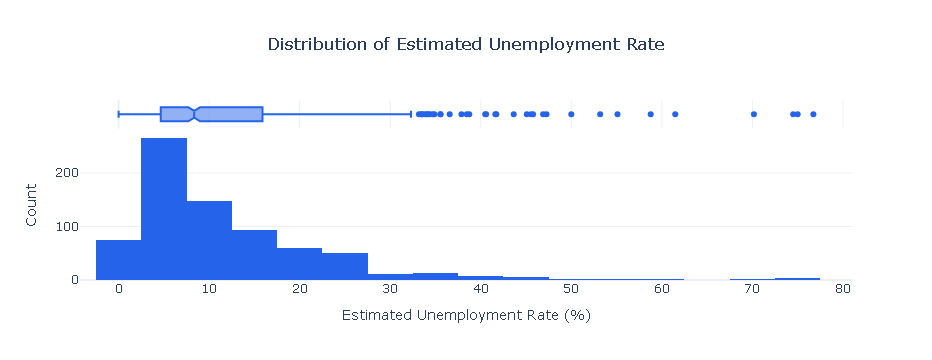

In [27]:
# ============================================================
# 📊 7.1 Distribution Analysis
# Estimated Unemployment Rate (%)
# ============================================================

fig = px.histogram(

    unemployment_df,

    x="Estimated Unemployment Rate (%)",

    marginal="box",

    nbins=30,

    color_discrete_sequence=["#2563EB"],

    title="Distribution of Estimated Unemployment Rate",

    template="plotly_white"

)

fig.update_layout(

    title_x=0.5,

    xaxis_title="Estimated Unemployment Rate (%)",

    yaxis_title="Count"

)

fig.show()

# Streamlit
# st.plotly_chart(fig, use_container_width=True)

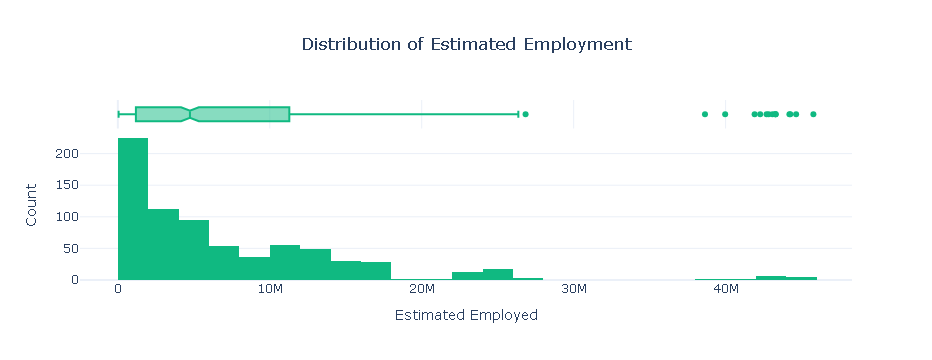

In [28]:
# ============================================================
# 📊 7.1.2 Distribution of Estimated Employment
# ============================================================

fig = px.histogram(

    unemployment_df,

    x="Estimated Employed",

    marginal="box",

    nbins=30,

    color_discrete_sequence=["#10B981"],

    title="Distribution of Estimated Employment",

    template="plotly_white"

)

fig.update_layout(

    title_x=0.5,

    xaxis_title="Estimated Employed",

    yaxis_title="Count"

)

fig.show()

# Streamlit
# st.plotly_chart(fig, use_container_width=True)

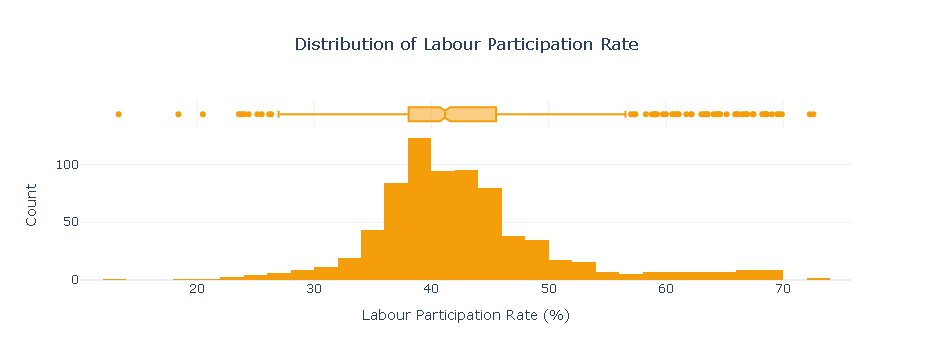

In [29]:
# ============================================================
# 📊 7.1.3 Distribution of Labour Participation Rate
# ============================================================

fig = px.histogram(

    unemployment_df,

    x="Estimated Labour Participation Rate (%)",

    marginal="box",

    nbins=30,

    color_discrete_sequence=["#F59E0B"],

    title="Distribution of Labour Participation Rate",

    template="plotly_white"

)

fig.update_layout(

    title_x=0.5,

    xaxis_title="Labour Participation Rate (%)",

    yaxis_title="Count"

)

fig.show()

# Streamlit
# st.plotly_chart(fig, use_container_width=True)

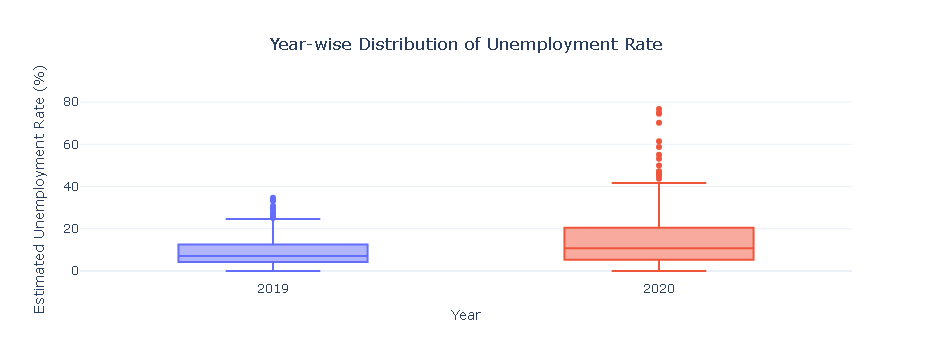

In [30]:
# ============================================================
# 📦 7.1.4 Year-wise Distribution of Unemployment Rate
# ============================================================

fig = px.box(

    unemployment_df,

    x="Year",

    y="Estimated Unemployment Rate (%)",

    color="Year",

    title="Year-wise Distribution of Unemployment Rate",

    template="plotly_white",

    points="outliers"

)

fig.update_layout(

    title_x=0.5,

    xaxis_title="Year",

    yaxis_title="Estimated Unemployment Rate (%)",

    showlegend=False

)

fig.show()

# Streamlit
# st.plotly_chart(fig, use_container_width=True)

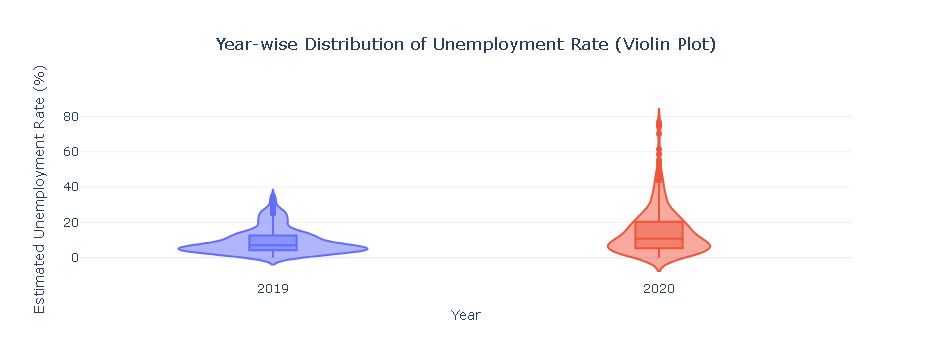

In [31]:
# ============================================================
# 🎻 7.1.5 Violin Plot of Unemployment Rate by Year
# ============================================================

fig = px.violin(

    unemployment_df,

    x="Year",

    y="Estimated Unemployment Rate (%)",

    color="Year",

    box=True,

    points="outliers",

    title="Year-wise Distribution of Unemployment Rate (Violin Plot)",

    template="plotly_white"

)

fig.update_layout(

    title_x=0.5,

    xaxis_title="Year",

    yaxis_title="Estimated Unemployment Rate (%)",

    showlegend=False

)

fig.show()

# Streamlit
# st.plotly_chart(fig, use_container_width=True)

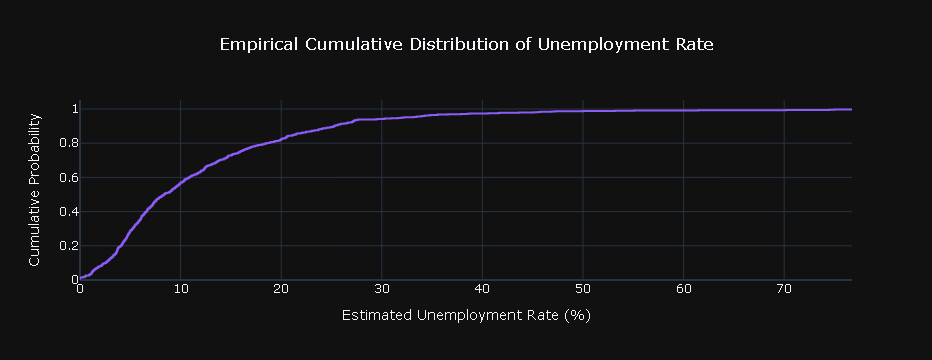

In [33]:
# ============================================================
# 📈 7.1.6 Empirical Cumulative Distribution Function (ECDF)
# ============================================================

fig = px.ecdf(

    unemployment_df,

    x="Estimated Unemployment Rate (%)",

    color_discrete_sequence=["#8B5CF6"],

    title="Empirical Cumulative Distribution of Unemployment Rate",

    template="plotly_dark"

)

fig.update_layout(

    title_x=0.5,

    xaxis_title="Estimated Unemployment Rate (%)",

    yaxis_title="Cumulative Probability"

)

fig.show()

# Streamlit
# st.plotly_chart(fig, use_container_width=True)

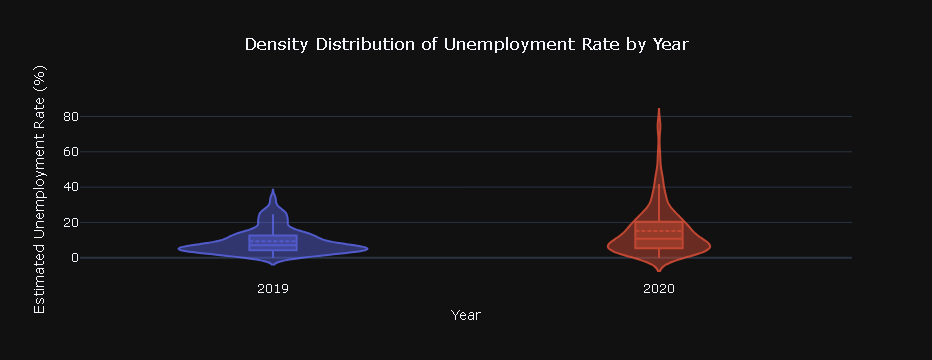

In [35]:
# ============================================================
# 📊 7.1.7 Density Distribution by Year
# ============================================================

fig = px.violin(

    unemployment_df,

    x="Year",

    y="Estimated Unemployment Rate (%)",

    color="Year",

    box=True,

    points=False,

    title="Density Distribution of Unemployment Rate by Year",

    template="plotly_dark"

)

fig.update_traces(

    meanline_visible=True,

    opacity=0.8

)

fig.update_layout(

    title_x=0.5,

    xaxis_title="Year",

    yaxis_title="Estimated Unemployment Rate (%)",

    showlegend=False

)

fig.show()

# Streamlit
# st.plotly_chart(fig, use_container_width=True)

# 📊 7.2 — Univariate Analysis

## 🎯 Objective

Univariate Analysis focuses on understanding the distribution and behavior of a single variable at a time.

In this section, we will analyze unemployment patterns across different time dimensions such as:

- 📅 Year
- 📆 Month
- 📊 Quarter
- 🌦️ Season

These analyses help identify long-term trends, seasonal effects, and recurring unemployment patterns.

---

## 📌 Charts Included

1. Year-wise Average Unemployment Rate
2. Month-wise Average Unemployment Rate
3. Quarter-wise Average Unemployment Rate
4. Season-wise Average Unemployment Rate
5. Monthly Employment Analysis
6. Monthly Labour Participation Analysis

---

## 🎯 Expected Outcome

This section will reveal:

- Annual unemployment trends
- Monthly fluctuations
- Seasonal patterns
- Economic cycles

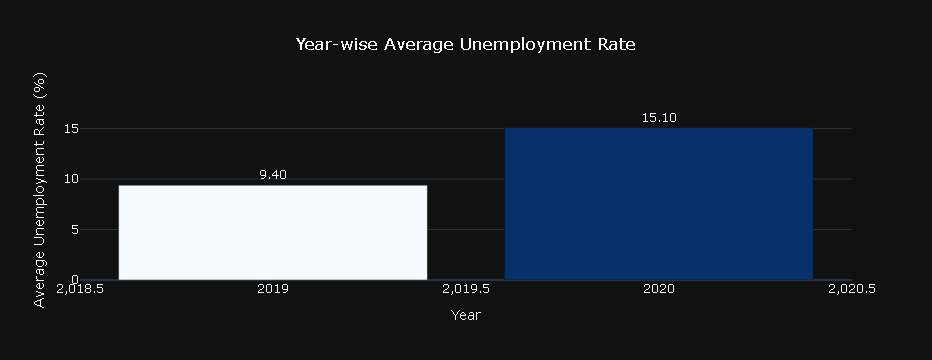

In [37]:
# ============================================================
# 📈 7.2.1 Year-wise Average Unemployment Rate
# ============================================================

yearly = (

    unemployment_df
    .groupby("Year", as_index=False)[
        "Estimated Unemployment Rate (%)"
    ]
    .mean()

)

fig = px.bar(

    yearly,

    x="Year",

    y="Estimated Unemployment Rate (%)",

    color="Estimated Unemployment Rate (%)",

    text_auto=".2f",

    color_continuous_scale="Blues",

    title="Year-wise Average Unemployment Rate",

    template="plotly_dark"

)

fig.update_layout(

    title_x=0.5,

    xaxis_title="Year",

    yaxis_title="Average Unemployment Rate (%)",

    coloraxis_showscale=False

)

fig.update_traces(

    textposition="outside"

)

fig.show()

# Streamlit
# st.plotly_chart(fig, use_container_width=True)

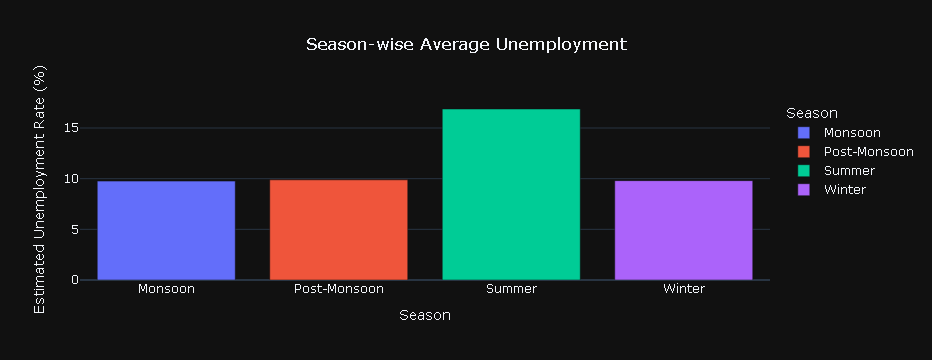

In [39]:
# ============================================================
# 🌦️ 7.2.4 Season-wise Average Unemployment
# ============================================================

season = (

    unemployment_df
    .groupby("Season", as_index=False)[
        "Estimated Unemployment Rate (%)"
    ]
    .mean()

)

fig = px.bar(

    season,

    x="Season",

    y="Estimated Unemployment Rate (%)",

    color="Season",

    title="Season-wise Average Unemployment",

    template="plotly_dark"

)

fig.update_layout(title_x=0.5)

fig.show()


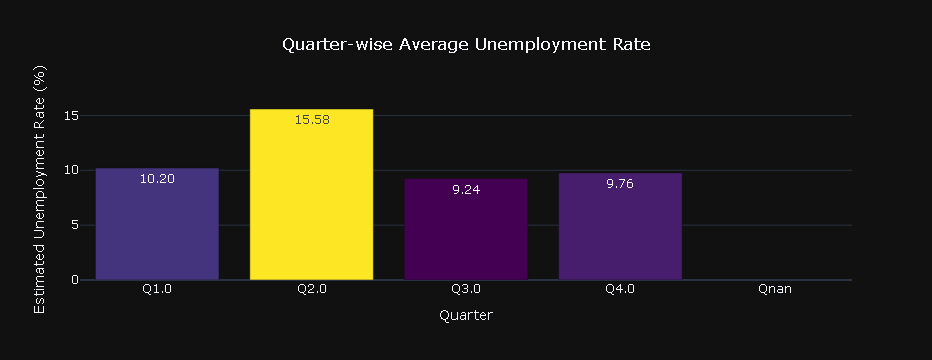

In [40]:
# ============================================================
# 📊 7.2.3 Quarter-wise Average Unemployment
# ============================================================

quarterly = (

    unemployment_df
    .groupby("Quarter", as_index=False)[
        "Estimated Unemployment Rate (%)"
    ]
    .mean()

)

fig = px.bar(

    quarterly,

    x="Quarter",

    y="Estimated Unemployment Rate (%)",

    color="Estimated Unemployment Rate (%)",

    text_auto=".2f",

    color_continuous_scale="Viridis",

    title="Quarter-wise Average Unemployment Rate",

    template="plotly_dark"

)

fig.update_layout(

    title_x=0.5,

    coloraxis_showscale=False

)

fig.show()

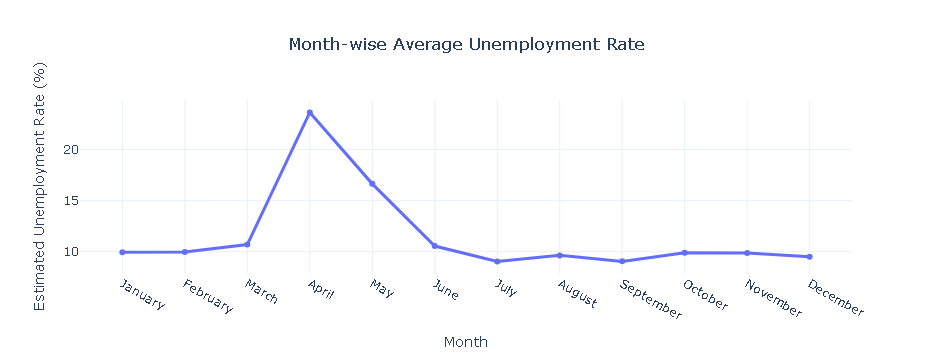

In [43]:
# ============================================================
# 📅 7.2.2 Month-wise Average Unemployment Rate
# ============================================================

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly = (

    unemployment_df
    .groupby("Month", as_index=False)[
        "Estimated Unemployment Rate (%)"
    ]
    .mean()

)

monthly["Month"] = pd.Categorical(
    monthly["Month"],
    categories=month_order,
    ordered=True
)

monthly = monthly.sort_values("Month")

fig = px.line(

    monthly,

    x="Month",

    y="Estimated Unemployment Rate (%)",

    markers=True,

    title="Month-wise Average Unemployment Rate",

    template="plotly_white"

)

fig.update_traces(line=dict(width=3))

fig.update_layout(title_x=0.5)

fig.show()

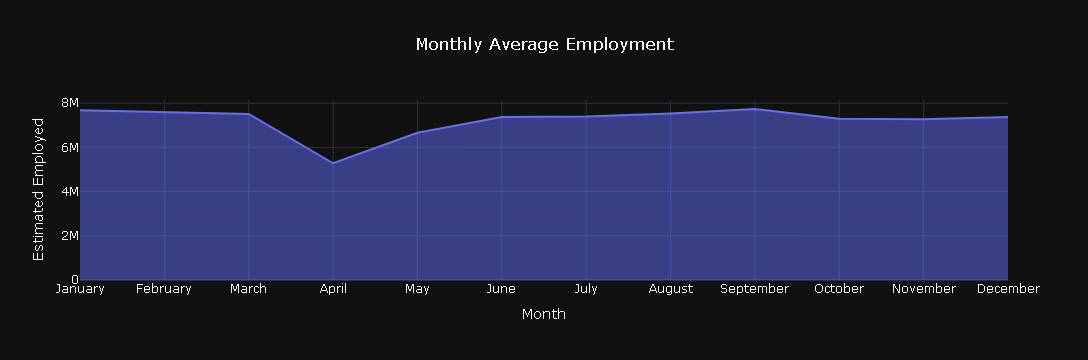

In [45]:
# ============================================================
# 👨‍💼 7.2.5 Monthly Average Employment
# ============================================================

employment = (

    unemployment_df
    .groupby("Month", as_index=False)[
        "Estimated Employed"
    ]
    .mean()

)

employment["Month"] = pd.Categorical(

    employment["Month"],

    categories=month_order,

    ordered=True

)

employment = employment.sort_values("Month")

fig = px.area(

    employment,

    x="Month",

    y="Estimated Employed",

    title="Monthly Average Employment",

    template="plotly_dark"

)

fig.update_layout(title_x=0.5)

fig.show()

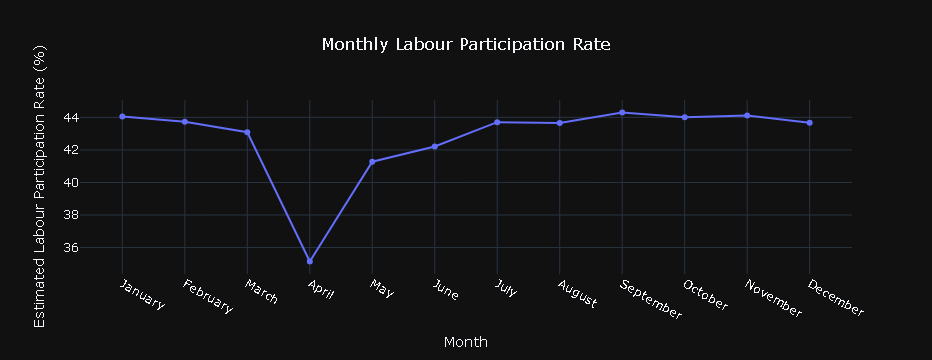

In [46]:
# ============================================================
# 👷 7.2.6 Monthly Labour Participation
# ============================================================

labour = (

    unemployment_df
    .groupby("Month", as_index=False)[
        "Estimated Labour Participation Rate (%)"
    ]
    .mean()

)

labour["Month"] = pd.Categorical(

    labour["Month"],

    categories=month_order,

    ordered=True

)

labour = labour.sort_values("Month")

fig = px.line(

    labour,

    x="Month",

    y="Estimated Labour Participation Rate (%)",

    markers=True,

    title="Monthly Labour Participation Rate",

    template="plotly_dark"

)

fig.update_layout(title_x=0.5)

fig.show()

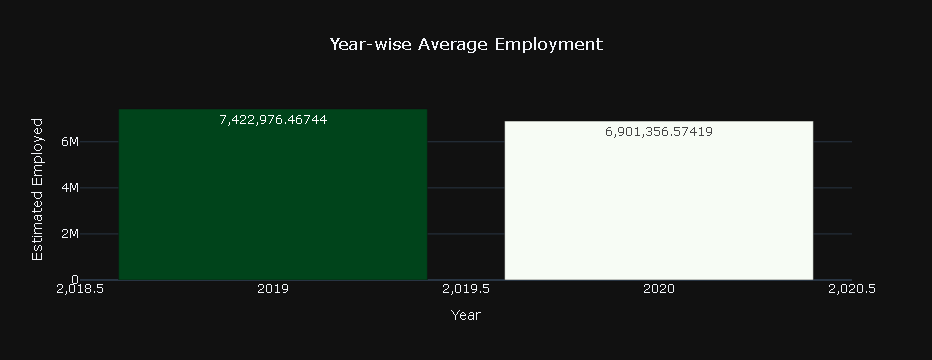

In [47]:
# ============================================================
# 📈 7.2.7 Year-wise Average Employment
# ============================================================

year_emp = (

    unemployment_df
    .groupby("Year", as_index=False)[
        "Estimated Employed"
    ]
    .mean()

)

fig = px.bar(

    year_emp,

    x="Year",

    y="Estimated Employed",

    color="Estimated Employed",

    text_auto=",",

    color_continuous_scale="Greens",

    title="Year-wise Average Employment",

    template="plotly_dark"

)

fig.update_layout(

    title_x=0.5,

    coloraxis_showscale=False

)

fig.show()

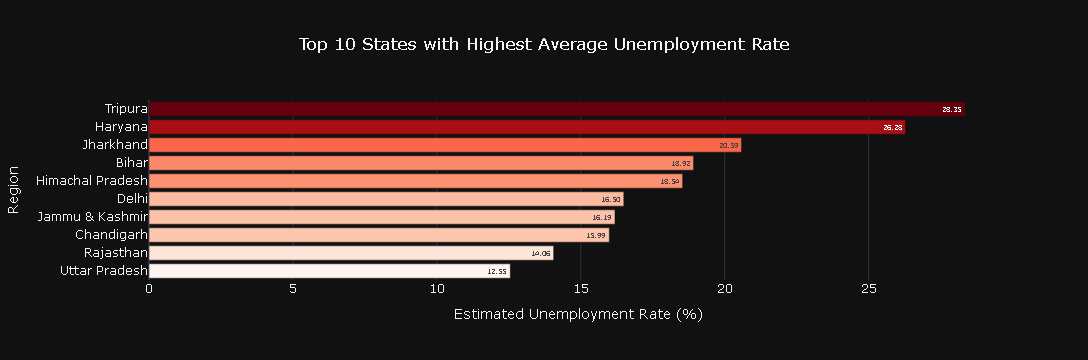

In [49]:
# ============================================================
# 🏆 Top 10 States with Highest Average Unemployment Rate
# ============================================================

top10 = (

    unemployment_df
    .groupby("Region", as_index=False)["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(
        "Estimated Unemployment Rate (%)",
        ascending=False
    )
    .head(10)

)

fig = px.bar(

    top10,

    x="Estimated Unemployment Rate (%)",

    y="Region",

    orientation="h",

    color="Estimated Unemployment Rate (%)",

    color_continuous_scale="Reds",

    text_auto=".2f",

    title="Top 10 States with Highest Average Unemployment Rate",

    template="plotly_dark"

)

fig.update_layout(

    title_x=0.5,

    yaxis=dict(categoryorder="total ascending"),

    coloraxis_showscale=False

)

fig.show()

# Streamlit
# st.plotly_chart(fig, use_container_width=True)

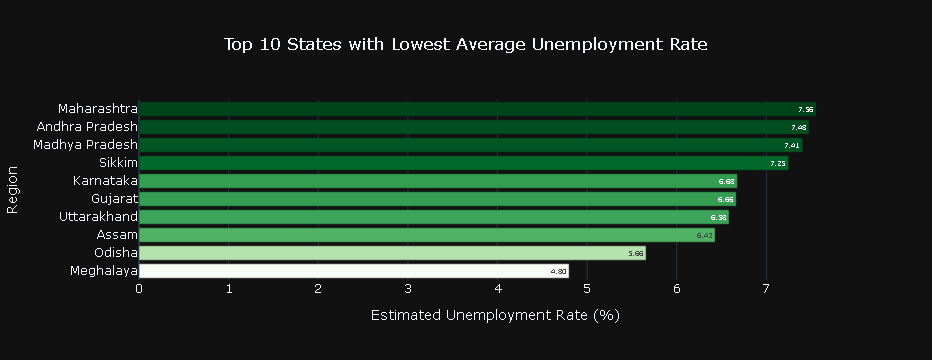

In [50]:
# ============================================================
# 🥇 Top 10 States with Lowest Average Unemployment Rate
# ============================================================

bottom10 = (

    unemployment_df
    .groupby("Region", as_index=False)["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(
        "Estimated Unemployment Rate (%)"
    )
    .head(10)

)

fig = px.bar(

    bottom10,

    x="Estimated Unemployment Rate (%)",

    y="Region",

    orientation="h",

    color="Estimated Unemployment Rate (%)",

    color_continuous_scale="Greens",

    text_auto=".2f",

    title="Top 10 States with Lowest Average Unemployment Rate",

    template="plotly_dark"

)

fig.update_layout(

    title_x=0.5,

    yaxis=dict(categoryorder="total ascending"),

    coloraxis_showscale=False

)

fig.show()

# Streamlit
# st.plotly_chart(fig, use_container_width=True)

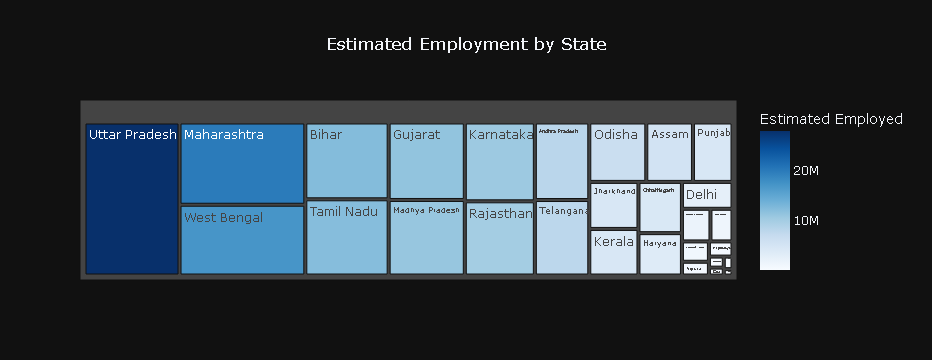

In [51]:
# ============================================================
# 🌳 Treemap of Estimated Employment by State
# ============================================================

employment_state = (

    unemployment_df
    .groupby("Region", as_index=False)["Estimated Employed"]
    .mean()

)

fig = px.treemap(

    employment_state,

    path=["Region"],

    values="Estimated Employed",

    color="Estimated Employed",

    color_continuous_scale="Blues",

    title="Estimated Employment by State",

    template="plotly_dark"

)

fig.update_layout(title_x=0.5)

fig.show()

# Streamlit
# st.plotly_chart(fig, use_container_width=True)

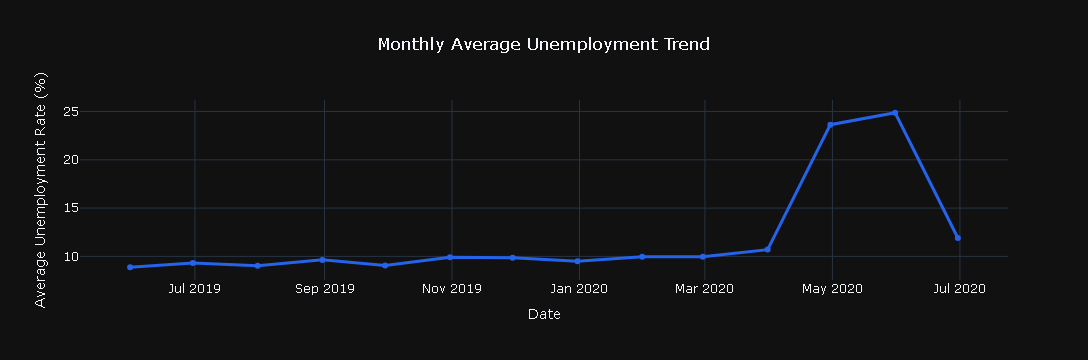

In [55]:
# ============================================================
# 📈 Monthly Average Unemployment Trend
# ============================================================

monthly_trend = (

    unemployment_df

    .groupby("Date", as_index=False)[
        "Estimated Unemployment Rate (%)"
    ]

    .mean()

    .sort_values("Date")

)

fig = px.line(

    monthly_trend,

    x="Date",

    y="Estimated Unemployment Rate (%)",

    markers=True,

    title="Monthly Average Unemployment Trend",

    template="plotly_dark"

)

fig.update_traces(

    line=dict(color="#2563EB", width=3)

)

fig.update_layout(

    title_x=0.5,

    xaxis_title="Date",

    yaxis_title="Average Unemployment Rate (%)"

)

fig.show()

# Streamlit
# st.plotly_chart(fig, use_container_width=True)

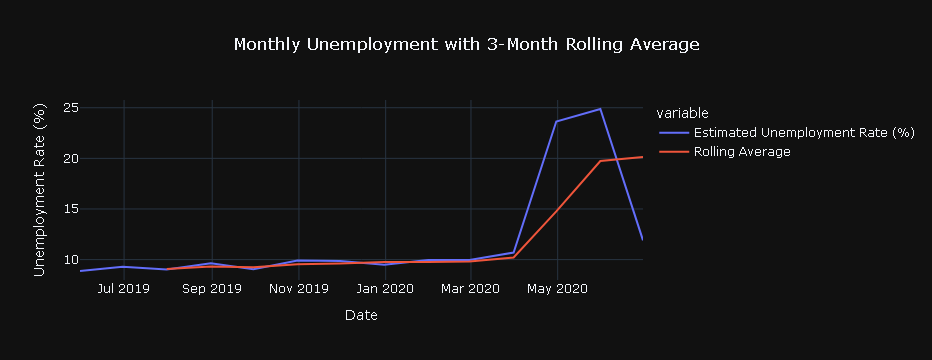

In [56]:
# ============================================================
# 📉 3-Month Rolling Average
# ============================================================

rolling = monthly_trend.copy()

rolling["Rolling Average"] = (

    rolling["Estimated Unemployment Rate (%)"]

    .rolling(window=3)

    .mean()

)

fig = px.line(

    rolling,

    x="Date",

    y=["Estimated Unemployment Rate (%)", "Rolling Average"],

    title="Monthly Unemployment with 3-Month Rolling Average",

    template="plotly_dark"

)

fig.update_layout(

    title_x=0.5,

    xaxis_title="Date",

    yaxis_title="Unemployment Rate (%)"

)

fig.show()

# Streamlit
# st.plotly_chart(fig, use_container_width=True)

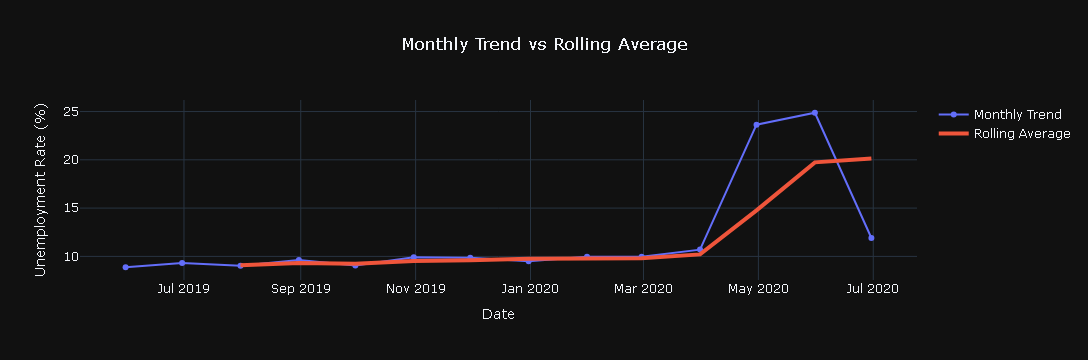

In [57]:
# ============================================================
# 📊 Trend vs Moving Average
# ============================================================

fig = go.Figure()

fig.add_trace(

    go.Scatter(

        x=rolling["Date"],

        y=rolling["Estimated Unemployment Rate (%)"],

        mode="lines+markers",

        name="Monthly Trend"

    )

)

fig.add_trace(

    go.Scatter(

        x=rolling["Date"],

        y=rolling["Rolling Average"],

        mode="lines",

        name="Rolling Average",

        line=dict(width=4)

    )

)

fig.update_layout(

    template="plotly_dark",

    title="Monthly Trend vs Rolling Average",

    title_x=0.5,

    xaxis_title="Date",

    yaxis_title="Unemployment Rate (%)"

)

fig.show()

# Streamlit
# st.plotly_chart(fig, use_container_width=True)

In [59]:
# ============================================================
# Create COVID Period Feature
# ============================================================

# Ensure Date is datetime
unemployment_df["Date"] = pd.to_datetime(
    unemployment_df["Date"],
    errors="coerce"
)

# Create COVID Period
unemployment_df["COVID Period"] = np.where(
    unemployment_df["Date"] < "2020-03-01",
    "Before COVID",
    "During COVID"
)

# Verify
unemployment_df[["Date", "COVID Period"]].head()

,Date,COVID Period
0,2019-05-31,Before COVID
1,2019-06-30,Before COVID
2,2019-07-31,Before COVID
3,2019-08-31,Before COVID
4,2019-09-30,Before COVID


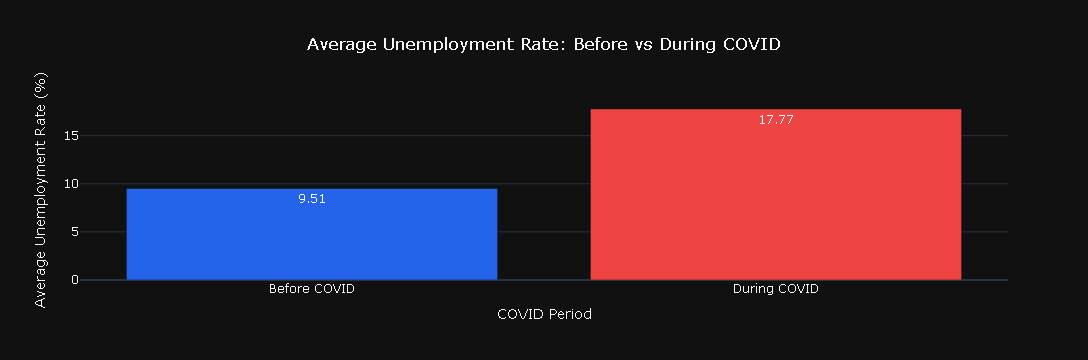

In [60]:
# ============================================================
# 🦠 Before vs During COVID
# ============================================================

covid = (

    unemployment_df

    .groupby("COVID Period", as_index=False)[
        "Estimated Unemployment Rate (%)"
    ]

    .mean()

)

fig = px.bar(

    covid,

    x="COVID Period",

    y="Estimated Unemployment Rate (%)",

    color="COVID Period",

    text_auto=".2f",

    title="Average Unemployment Rate: Before vs During COVID",

    color_discrete_sequence=["#2563EB", "#EF4444"],

    template="plotly_dark"

)

fig.update_layout(

    title_x=0.5,

    xaxis_title="COVID Period",

    yaxis_title="Average Unemployment Rate (%)",

    showlegend=False

)

fig.show()

# Streamlit
# st.plotly_chart(fig, use_container_width=True)

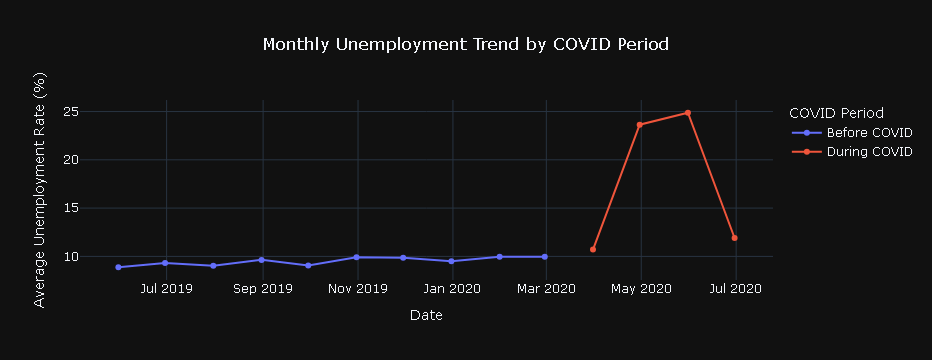

In [61]:
# ============================================================
# 📈 Monthly Trend During COVID
# ============================================================

covid_month = (

    unemployment_df

    .groupby(["Date", "COVID Period"], as_index=False)[
        "Estimated Unemployment Rate (%)"
    ]

    .mean()

)

fig = px.line(

    covid_month,

    x="Date",

    y="Estimated Unemployment Rate (%)",

    color="COVID Period",

    markers=True,

    title="Monthly Unemployment Trend by COVID Period",

    template="plotly_dark"

)

fig.update_layout(

    title_x=0.5,

    xaxis_title="Date",

    yaxis_title="Average Unemployment Rate (%)"

)

fig.show()

# Streamlit
# st.plotly_chart(fig, use_container_width=True)

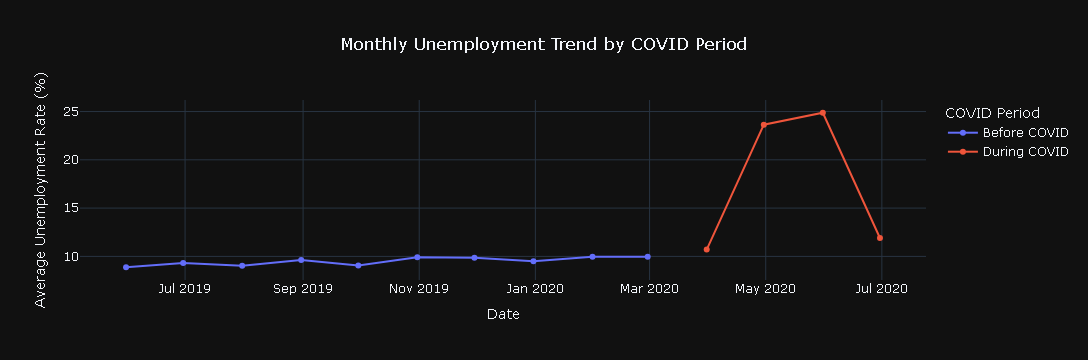

In [62]:
# ============================================================
# 📈 Monthly Trend During COVID
# ============================================================

covid_month = (

    unemployment_df

    .groupby(["Date", "COVID Period"], as_index=False)[
        "Estimated Unemployment Rate (%)"
    ]

    .mean()

)

fig = px.line(

    covid_month,

    x="Date",

    y="Estimated Unemployment Rate (%)",

    color="COVID Period",

    markers=True,

    title="Monthly Unemployment Trend by COVID Period",

    template="plotly_dark"

)

fig.update_layout(

    title_x=0.5,

    xaxis_title="Date",

    yaxis_title="Average Unemployment Rate (%)"

)

fig.show()

# Streamlit
# st.plotly_chart(fig, use_container_width=True

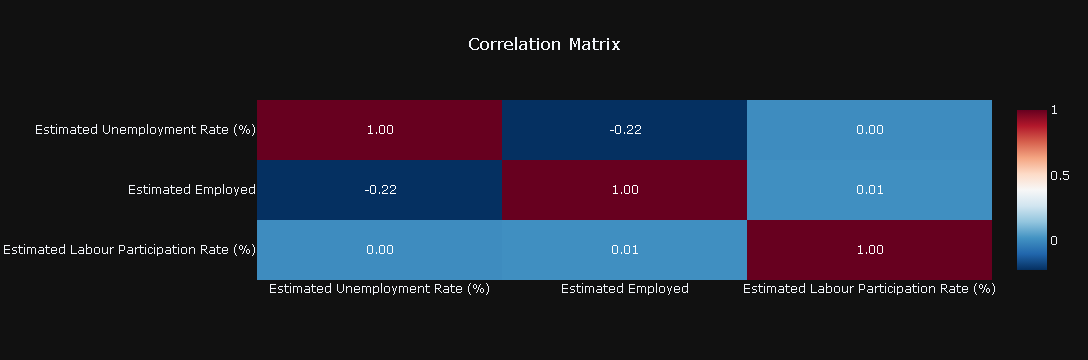

In [63]:
# ============================================================
# 🔥 Correlation Heatmap
# ============================================================

corr_columns = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]

corr = unemployment_df[corr_columns].corr()

fig = px.imshow(

    corr,

    text_auto=".2f",

    color_continuous_scale="RdBu_r",

    title="Correlation Matrix",

    template="plotly_dark",

    aspect="auto"

)

fig.update_layout(title_x=0.5)

fig.show()

# Streamlit
# st.plotly_chart(fig, use_container_width=True)